# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv
import pickle
import joblib

import inflect
import unicodedata
import re

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

# Data Cleaning functions

### Functions

#### optional string processing

In [20]:
def comma_to_left(string, index) -> bool:
    '''
    Checks if there is a comma to the left of the index in the string, ignoring spaces.
    '''
    while index >= 1:
        if string[index - 1] == ',':
            return True
        if string[index - 1] == ' ':
            index -= 1
        else:
            return False
    return False

def strip_optional_tags(string):
    '''
    Strips "optional" tags from the string, and strips descriptions of ingredients in parentheses
    '''
    # First, remove simple substrings
    string = string.replace("[", "").replace("]", "")
    string = string.replace("optionally", "").replace("optional", "")
    string = string.replace("such as", "")
    string = string.replace(":", "")
    string = string.replace("{", "").replace("}", "")
    
    # Handle parentheses: find all "("s
    # If no comma to the left, delete everything from "(" to ")"
    # If comma to the left, just delete "(" and ")"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            
            # Check if there's a comma to the left
            if comma_to_left(string, i):
                # Just delete "(" and ")", keep the content
                result.append(string[i+1:close_idx])
                i = close_idx + 1
            else:
                # Delete all text from "(" to ")" inclusive
                i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result)

def strip_optional_ingredients(string): # MAY NOT WORK
    '''
    Strips "optional" ingredients from the string, as well as descriptions of ingredients in parentheses.
    '''
    # First pass: Look for "(" or "[" from left to right
    # If one is found and there's a comma to the left, delete everything from that comma to the end
    i = 0
    while i < len(string):
        if string[i] in '([':
            if comma_to_left(string, i):
                # Delete everything from the comma to the end of the string
                j = i - 1
                while j >= 0:
                    if string[j] == ',':
                        string = string[:j]
                        break
                    j -= 1
                break
        i += 1
    
    # Second pass: Search for "(optional)" and "[optional]" repeatedly
    while True:
        idx1 = string.find("(optional)")
        idx2 = string.find("[optional]")
        
        if idx1 == -1 and idx2 == -1:
            break
        
        # Find which one comes first
        idx = -1
        pattern_len = 0
        if idx1 != -1 and idx2 != -1:
            idx = min(idx1, idx2)
            pattern_len = 10 if idx == idx1 else 10
        elif idx1 != -1:
            idx = idx1
            pattern_len = 10
        else:
            idx = idx2
            pattern_len = 10
        
        # Find the first comma to the left, delete from comma to end of pattern
        j = idx - 1
        comma_idx = -1
        while j >= 0:
            if string[j] == ',':
                comma_idx = j
                break
            j -= 1
        
        if comma_idx != -1:
            # Delete from comma to the end of the pattern
            string = string[:comma_idx] + string[idx + pattern_len:]
        else:
            # No comma found, just remove the pattern
            string = string[:idx] + string[idx + pattern_len:]
    
    # Final pass: Strip everything in parentheses, including the parentheses themselves
    # get rid of the descriptions of ingredients in parentheses, e.g. "kalabasa (squash)"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            # Skip everything from "(" to ")" inclusive
            i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result).strip()


def clean_ingredient_list(string):
    '''
    Strips whitespace and empty ingredients so that we can easily split by comma to get a clean list
    Also splits on "and", "or" and "/" and removes periods
    '''
    normalized = re.sub(r"\bor\b", ",", string, flags=re.IGNORECASE)
    normalized = re.sub(r"\band\b", ",", normalized, flags=re.IGNORECASE)
    normalized = re.sub(r"/", ",", normalized, flags=re.IGNORECASE)
    filtered = [ingredient.lower().replace(".", "").replace("(", "").replace(")", "").strip() for ingredient in normalized.split(",") if ingredient.strip()]
    return [ingredient for ingredient in filtered if ingredient.strip()] # get rid of empty string ings

def countries_to_array(string):
    '''
    Converts a string of countries separated by semicolons into an array of countries, stripping whitespace.
    '''
    return [country.strip() for country in string.split(";") if country.strip()]

#### collapse ingredient variants

In [4]:
p = inflect.engine()

# Normalize ingredient strings to collapse accent, apostrophe, and hyphen variants,
# while preserving spaces so canonical multi-word ingredients stay spaced.
def normalize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = unicodedata.normalize('NFKD', ingredient)
    ingredient = ''.join(ch for ch in ingredient if not unicodedata.combining(ch))
    ingredient = ingredient.lower()
    ingredient = ingredient.replace('-', ' ')
    ingredient = re.sub(r"[’`´]", "'", ingredient)
    ingredient = ingredient.replace("'", '')
    ingredient = re.sub(r'\s+', ' ', ingredient).strip()
    return ingredient

# Singularize ingredients after normalization
def singularize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    
    ingredient = normalize_ingredient(ingredient)
    
    # Split the phrase into individual words
    words = ingredient.split()
    singular_words = []
    
    for word in words:
        # p.singular_noun returns False if the word is already singular
        singular = p.singular_noun(word)
        if singular:
            singular_words.append(singular)
        else:
            singular_words.append(word)
            
    # Rejoin the words into a single string
    return " ".join(singular_words)

#### base ingredient detection

In [5]:
def most_common_one_word_ings(df, how_many=200):
    ingredients = df['ingredients'].explode()
    one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]
    return one_word_ingredients.value_counts().head(how_many).index.tolist()

# look for common one-word ingredients within ingredients list, eg. "garlic" in "minced garlic"
def get_base_ingredient_names(ingredient_list, most_common_ings):
    base_ingredients = []
    for ingredient in ingredient_list:
        for word in ingredient.split():
            if word in most_common_ings and word not in base_ingredients:
                base_ingredients.append(word)
    return base_ingredients

def add_base_ingredients(ingredient_list, most_common_ings):
    base_ingredients = get_base_ingredient_names(ingredient_list, most_common_ings)
    return list(set(ingredient_list) | set(base_ingredients))

#### ingredient detection within parentheses

In [6]:
# look for the common ings inside the descriptions...
def get_base_ings_from_string(raw_string, most_common_ings):

    if not isinstance(raw_string, str):
        return []

    # normalize
    raw_string = normalize_ingredient(raw_string)

    # singularize EACH TOKEN separately
    tokens = []

    for token in re.findall(r"\b\w+\b", raw_string):

        singular = p.singular_noun(token)

        if singular:
            tokens.append(singular)
        else:
            tokens.append(token)

    normalized_string = " ".join(tokens)

    ings_found = []

    for ing in most_common_ings:

        normalized_ing = singularize_ingredient(
            ing.replace("_", " ")
        )

        pattern = r"\b" + re.escape(normalized_ing) + r"\b"

        if re.search(pattern, normalized_string):
            ings_found.append(ing)

    return list(set(ings_found))

# Data Cleaning

#### Testing

In [14]:
print(strip_optional_tags("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_tags("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_tags("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_tags("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_tags("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_tags("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_tags("salt, (optional garlic), (optional sugar)"))
print(strip_optional_tags("salt, kalabasa (squash)"))
print(strip_optional_tags("salt, kalabasa (squash), (optional) garlic"))

print("\n" + strip_optional_tags("salt, sugar, (optionally pepper), (optional garlic)"))
print(strip_optional_tags("Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish, (optional pickled mustard greens, optional apple slices, optional sesame seeds)."))
print(strip_optional_tags("salt, (mushrooms optional), (peas optional),"))

salt, sugar, pepper , garlic , onion 
salt,  garlic, sugar, etc.
salt, sugar, pepper , garlic , onion 
salt, sugar,  pepper,  garlic,  onion
salt, green onions , red onions 
salt,  garlic,  sugar
salt,  garlic,  sugar
salt, kalabasa 
salt, kalabasa ,  garlic

salt, sugar,  pepper,  garlic
Cold noodles, sliced beef, beef broth, kimchi, boiled egg, cucumber, radish,  pickled mustard greens,  apple slices,  sesame seeds.
salt, mushrooms , peas ,


In [15]:
print(strip_optional_ingredients("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_ingredients("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_ingredients("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_ingredients("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_ingredients("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_ingredients("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_ingredients("salt, (optional garlic), (optional sugar)"))
print(strip_optional_ingredients("salt, kalabasa (squash)"))
print(strip_optional_ingredients("salt, kalabasa (squash), (optional) garlic"))

salt, sugar
salt
salt, sugar
salt, sugar
salt
salt
salt
salt, kalabasa
salt, kalabasa


In [16]:
clean_ingredient_list("salt   , meat or fish, and shrimp,     onion/shallot, etc")

['salt', 'meat', 'fish', 'shrimp', 'onion', 'shallot', 'etc']

### Overview / optional ingredient processing

In [10]:
df = pd.read_csv('data/data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [11]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [12]:
cleaned_df['countries_of_origin'].explode().value_counts().head(15) / len(cleaned_df) * 100.0

countries_of_origin
United States     6.566667
Japan             4.833333
Indonesia         4.433333
United Kingdom    4.400000
China             4.400000
Italy             4.366667
Philippines       4.266667
India             3.733333
Spain             3.733333
France            3.666667
Germany           3.300000
South Korea       3.266667
Canada            3.100000
Turkey            2.633333
North Korea       2.533333
Name: count, dtype: float64

In [13]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

1742

Text(0.5, 0, 'Number of dishes for country of origin')

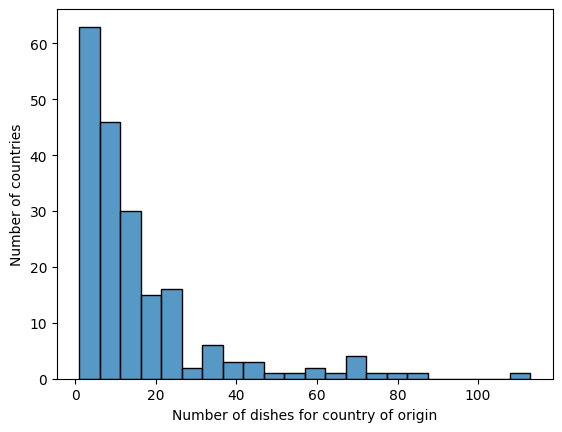

In [14]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())
plt.ylabel("Number of countries")
plt.xlabel("Number of dishes for country of origin")

In [15]:
# countries included if cutting off least frequent 150 countries
unique_dishes_df['countries_of_origin'].explode().value_counts().head(197 - 150)

countries_of_origin
United States     113
Japan              83
United Kingdom     80
China              73
Italy              72
Indonesia          72
Philippines        71
India              70
France             66
Spain              62
Germany            60
South Korea        53
Canada             51
Thailand           46
Turkey             43
Mexico             43
Malaysia           40
North Korea        40
Vietnam            37
Peru               35
Iran               34
Georgia            34
Australia          34
Brazil             32
Singapore          32
Sweden             31
Azerbaijan         28
Poland             26
Russia             26
Armenia            26
Taiwan             25
Algeria            25
Romania            24
Nepal              24
Pakistan           24
Greece             23
Colombia           23
Egypt              23
Hong Kong          23
Myanmar            22
Tunisia            22
Netherlands        22
Bangladesh         22
New Zealand        21
Ukraine     

In [16]:
unique_dishes_df['countries_of_origin'].explode().value_counts().iloc[50:100]

countries_of_origin
Portugal                  20
Serbia                    20
Denmark                   19
Sri Lanka                 19
Lithuania                 19
Nigeria                   19
Lebanon                   17
Belarus                   17
Morocco                   16
Belgium                   16
Bulgaria                  16
Chile                     16
South Africa              16
Syria                     16
Slovenia                  16
Palestine                 16
Cyprus                    15
Libya                     15
Norway                    15
Jordan                    15
Switzerland               15
Cuba                      14
Ecuador                   14
Ireland                   14
Trinidad and Tobago       14
Bolivia                   14
Laos                      14
Iraq                      14
Bosnia and Herzegovina    13
North Macedonia           13
Moldova                   13
Israel                    13
Macau                     13
Mauritania             

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [17]:
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [18]:
from fuzzywuzzy import fuzz
from itertools import combinations

ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()
pairs = list(combinations(ingredients, 2))

# Calculate similarities
#similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]
#similarities.sort(key=lambda x: x[1], reverse=True)

In [19]:
#similarities[:40]

In [20]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      968
garlic    720
onion     615
sugar     531
water     423
egg       380
butter    366
pepper    349
flour     297
tomato    275
Name: count, dtype: int64

### Make connections between base and processed ingredient names ("Raw fish" and "fish" are related)

In [21]:
ingredients = unique_dishes_df['ingredients'].explode()

one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]

len(one_word_ingredients.value_counts())

603

In [22]:
most_common_200 = most_common_one_word_ings(unique_dishes_df)
add_base_ingredients(["green onion", "red onion", "minced garlic", "garlic", "raw chicken", "rice", "ube jam"], most_common_200)

['onion',
 'minced garlic',
 'green onion',
 'ube jam',
 'chicken',
 'garlic',
 'jam',
 'rice',
 'raw chicken',
 'red onion']

In [23]:
# add the base ingredients of processed ingredient names to list of ingredients to give model more context
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(add_base_ingredients, most_common_ings=most_common_200)

### Extract additional info within parentheses like "vegetables (such as onions and cucumbers)"

In [24]:
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Dak-galbi", 'ingredients'].iloc[0]

['soy sauce',
 'perilla leaf',
 'ginger',
 'cheese',
 'oil',
 'potato',
 'sweet potato',
 'green cabbage',
 'gochujang',
 'scallion',
 'carrot',
 'rice cake',
 'sesame oil',
 'chicken',
 'sesame seed',
 'garlic',
 'rice',
 'cabbage',
 'mozzarella cheese']

In [25]:
# also look for the 200 most common ing names within the original ingredient string to grab potential ings that were wiped
# eg for "vegetables (such as okra and spinach)", everything inside () is thrown away and okra and spinach are lost
name_to_original_description = df.copy().drop(["countries_of_origin", "alternate_names"], axis=1).drop_duplicates(subset=['dish_name'])

name_to_original_description['base ings'] = name_to_original_description['ingredients'].apply(get_base_ings_from_string, most_common_ings=most_common_200)

# add base ings to ing list of dishes in unique_dishes_df
unique_dishes_df = unique_dishes_df.merge(
    name_to_original_description[['dish_name', 'base ings']], 
    on='dish_name', 
    how='left'
)

# Combine the two lists and remove duplicates
unique_dishes_df['ingredients'] = unique_dishes_df.apply(
    lambda row: list(set(
        (row['ingredients'] if isinstance(row['ingredients'], list) else []) + 
        (row['base ings'] if isinstance(row['base ings'], list) else [])
    )), 
    axis=1
)

unique_dishes_df.drop('base ings', axis=1, inplace=True)

In [26]:
# looks like it worked!
'Tempura,Japan,"Seafood (such as shrimp, squid, or fish), vegetables (such as sweet potatoes, onions, and bell peppers), flour, cornstarch, baking soda, ice water,'
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Tempura", 'ingredients'].iloc[0]

['corn starch',
 'onion',
 'fish',
 'ice',
 'baking soda',
 'ice water',
 'flour',
 'potato',
 'pepper',
 'squid',
 'shrimp',
 'seafood',
 'water',
 'corn',
 'starch',
 'vegetable']

In [27]:
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Dak-galbi", 'ingredients'].iloc[0]

['potato',
 'green cabbage',
 'gochujang',
 'scallion',
 'carrot',
 'rice cake',
 'chicken',
 'sesame seed',
 'mozzarella cheese',
 'ginger',
 'soy sauce',
 'perilla leaf',
 'cheese',
 'oil',
 'sweet potato',
 'sesame oil',
 'garlic',
 'rice',
 'cabbage']

### Get rid of spacing

In [28]:
# replace spaces with underscore
# (makes processing ingredients from predictions easier)
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(lambda lst: [ing.replace(' ', '_') for ing in lst])

unique_dishes_df.loc[:, 'ingredients'].head()

0    [meat, onion, potato, pepper, egg, bacon, crea...
1    [tahini, olive_oil, oil, cumin, pepper, olive,...
2    [orange_zest, olive_oil, oil, nutmeg, orange, ...
3    [meat, bread_crumb, crab_meat, cayenne_pepper,...
4    [potato, green_cabbage, gochujang, scallion, c...
Name: ingredients, dtype: object

### Save processed data

In [ ]:
unique_dishes_df.to_csv('TEST_unique_processed_data.csv', index=False)

###

# Label processing + misc functions

In [11]:
def process_training_data(train_df, label_scheme='most_common', drop_scheme=150, uncommon_filter_threshold=50):
    '''
    Processes the training data according to the specified label scheme and drop scheme.
    '''
    train_country_counts = train_df['countries_of_origin'].explode().value_counts()

    ### Different schemes for converting multi-label examples in the training set to single labels ###
    if label_scheme == 'most_common':
        # use most common country in the training set for label of multi-label examples
        def most_common_country(country_list):
            if not country_list:
                return np.nan
            ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
            return ranked[0]

        train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

    elif label_scheme == 'use_all':
        # expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)
    
    elif label_scheme == 'filter_uncommon':
        # filter out less common countries from multilabel training examples
        more_common_countries = train_country_counts.head(uncommon_filter_threshold).index 

        def filter_uncommon_countries(country_list):
            for country in country_list:
                if country in more_common_countries:  # if a more common country is present, keep it and filter out the uncommon ones
                    return [c for c in country_list if c in more_common_countries]
            
            return country_list
        
        train_df['countries_of_origin'] = train_df['countries_of_origin'].apply(filter_uncommon_countries)
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

    else:
        raise ValueError(f'Unknown label scheme: {label_scheme}')
    

    ### Drop uncommon countries from training set according to drop scheme ###
    if drop_scheme is not None:
        # filter out less common countries from the training set to reduce noise
        uncommon_countries = train_country_counts.tail(drop_scheme).index
        train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]

    return train_df

def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Models

### Train/test split + training label conversion

In [73]:
# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

train_df = process_training_data(train_df, label_scheme='filter_uncommon', uncommon_filter_threshold=100, drop_scheme=None)


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())



Training rows: 2252
Test rows: 349
Training country counts: {'United States': 92, 'Japan': 63, 'Indonesia': 62, 'China': 60, 'United Kingdom': 57, 'Spain': 56, 'Philippines': 54, 'Italy': 54, 'France': 52, 'Germany': 50}
Example test labels (multi-country): [['Japan'], ['North Korea', 'South Korea'], ['Nigeria'], ['Vietnam'], ['Vietnam']]


### Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.25787965616045844

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Russia, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Georgia, actual=['Vietnam'], incorrect
Bánh Giầy: predicted China, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Thailand, actual=['Suriname'], incorrect
Speculaas: predicted Germany, actual=['Belgium', 'Netherlands', 'Germany'], correct

Top ingredient importances:
shallot        0.019164
cilantro       0.018550
mirin          0.017307
ginger         0.016463
egg            0.015483
olive oil      0.015157
green chili    0.013416
salt           0.012361
po

### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.3954154727793696

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted South Korea, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted United States, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Mexico, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water        0.011429
salt         0.011344
olive        0.010453
egg          0.010251
oil          0.010116
rice         0.010082
onion        0.010003
olive oil    0.009271
s

In [25]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

United Kingdom    10.028653
United States      8.309456
India              8.022923
Italy              7.449857
Philippines        6.590258
France             6.303725
Mexico             4.871060
Germany            4.871060
Thailand           4.584527
Japan              4.297994
South Korea        3.438395
Spain              2.865330
Vietnam            2.578797
Indonesia          2.578797
Iran               2.292264
Austria            2.292264
Turkey             2.292264
Canada             1.719198
China              1.719198
Peru               1.719198
Australia          1.432665
Colombia           1.432665
Brazil             1.432665
Romania            1.146132
Algeria            0.859599
North Korea        0.859599
Russia             0.859599
Sweden             0.573066
Tunisia            0.573066
Malaysia           0.573066
Egypt              0.573066
Georgia            0.286533
Greece             0.286533
Taiwan             0.286533
Name: count, dtype: float64

### Balanced Random Forest

In [59]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2293) Test set: (349, 2293)
Hold-out accuracy (single-label prediction vs. any true country): 0.3839541547277937

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted Japan, actual=['Japan'], correct
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Brazil, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Peru, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water           0.011931
egg             0.011203
salt            0.010826
ice             0.010403
oil             0.009870
onion           0.009731
garlic          0.009133
flour           0.0

### XGBoost

In [98]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import compute_sample_weight

# example display count
n = 8
display_ings = False

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

clf = XGBClassifier(n_estimators=100, max_depth=30, learning_rate=0.1, reg_lambda = 1, random_state=42, 
                    objective='multi:softmax', num_class=len(le.classes_))  #####################################################
clf.fit(X_train, y_train_encoded)
y_pred = clf.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred_labels, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual_list, dish in zip(
    y_pred_labels,
    y_test_multi.head(n),
    test_df['dish_name'].head(n)
):
    actual_list = actual_list if isinstance(actual_list, (list, tuple)) else [actual_list]

    print(f'{dish}: predicted {pred}, actual={actual_list}, {"correct" if pred in actual_list else "incorrect"}')

    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(30).to_string())

Train set: (2252, 2293) Test set: (349, 2293)
Hold-out accuracy (single-label prediction vs. any true country): 0.35816618911174786

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Nigeria, actual=['Nigeria'], correct
Gỏi Cuốn: predicted Taiwan, actual=['Vietnam'], incorrect
Bánh Giầy: predicted Taiwan, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Nicaragua, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
mirin              0.051093
parmesan_cheese    0.025699
shallot            0.014464
dashi              0.014308
salsa              0.011412
chorizo            0.011227
sesame_oil       

In [80]:
display_ingredients("Gỏi Cuốn")

'rice paper, shrimp, pork, rice vermicelli, lettuce, mint, thai basil, cilantro, garlic chives, bean sprouts, cucumber, carrot, hoisin sauce, peanut sauce'

# Model CV

### Decision Tree

In [23]:
from sklearn.model_selection import KFold

def run_cv_decision_tree(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, max_depth=100, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = DecisionTreeClassifier(max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [27]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['most_common', 'use_all', 'filter_uncommon']
drop_schemes = [150, 100, 50, 30, None] # drop bottom 150 consistently underperforms
max_depths = [50, 75, 100, 150]
class_weights = [None, 'balanced'] # balanced consistently underperforms on this data

results_dict = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(max_depths) * len(class_weights)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for depth in max_depths:
            for weight in class_weights:
                print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                accuracies, mean_acc, std_acc = run_cv_decision_tree(
                    df=model_df,
                    folds=5,
                    label_scheme=scheme,
                    drop_scheme=drop,
                    max_depth=depth,
                    class_weight=weight
                )
                results_dict[(scheme, drop, depth, weight)] = (accuracies, mean_acc, std_acc)
                current_run += 1

print('done!')

Run 120/120...done!


In [28]:
print('Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy')
for key, value in sorted(results_dict.items(), key=lambda x: x[1][1], reverse=True):
    print(f'{key}: {value[1]:.4f} ± {value[2]:.4f}')

Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy
('most_common', 50, 75, None): 0.2801 ± 0.0177
('most_common', 50, 150, None): 0.2750 ± 0.0117
('most_common', 50, 100, None): 0.2738 ± 0.0108
('most_common', None, 75, None): 0.2733 ± 0.0145
('most_common', 100, 75, None): 0.2686 ± 0.0202
('most_common', None, 100, None): 0.2681 ± 0.0130
('most_common', None, 150, None): 0.2681 ± 0.0130
('most_common', None, 50, None): 0.2669 ± 0.0142
('most_common', 100, 150, None): 0.2669 ± 0.0237
('most_common', 50, 50, None): 0.2669 ± 0.0172
('most_common', 100, 100, None): 0.2658 ± 0.0216
('most_common', 30, 150, None): 0.2618 ± 0.0148
('filter_uncommon', 30, 50, None): 0.2606 ± 0.0119
('most_common', 100, 50, None): 0.2606 ± 0.0195
('most_common', 30, 75, None): 0.2601 ± 0.0195
('most_common', 30, 100, None): 0.2595 ± 0.0161
('filter_uncommon', 50, 100, None): 0.2583 ± 0.0140
('filter_uncommon', 100, 150, None): 0.2566 ± 0.0227
('filter_uncommon', 30, 75

### Random Forest

In [96]:
from sklearn.model_selection import KFold

def run_cv_random_forest(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, n_estimators=100, max_depth=30, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [40]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['filter_uncommon']
drop_schemes = [50, None]
n_estimators_list = [300]
max_depths = [50]
class_weights = [None]
uncommon_filter_thresholds = [30, 50, 100]

results_dict_rf = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(n_estimators_list) * len(max_depths) * len(class_weights) * len(uncommon_filter_thresholds)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for n_estimators in n_estimators_list:
            for depth in max_depths:
                for weight in class_weights:
                    for uncommon_filter_threshold in uncommon_filter_thresholds:
                        print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                        accuracies, mean_acc, std_acc = run_cv_random_forest(
                            df=model_df,
                            folds=5,
                            label_scheme=scheme,
                            drop_scheme=drop,
                            n_estimators=n_estimators,
                            max_depth=depth,
                            class_weight=weight,
                            uncommon_filter_threshold=uncommon_filter_threshold
                        )
                        results_dict_rf[(scheme, drop, n_estimators, depth, weight, uncommon_filter_threshold)] = (accuracies, mean_acc, std_acc)
                        current_run += 1

print('done!')

Run 6/6...done!


In [ ]:
print('Results (scheme, drop, n_estimators, max_depth, class_weight, uncommon_filter_threshold): mean accuracy ± std accuracy')
for key, value in sorted(results_dict_rf.items(), key=lambda x: x[1][1], reverse=True)[:20]:
    print(f'{key}: {value[1]:.3f} ± {value[2]:.3f}                      {[f"{val:.3f}" for val in value[0]]}')

Results (scheme, drop, n_estimators, max_depth, class_weight): mean accuracy ± std accuracy
('filter_uncommon', None, 300, 50, None, 50): 0.410 ± 0.022                      ['0.418', '0.401', '0.448', '0.399', '0.385']
('filter_uncommon', 50, 300, 50, None, 100): 0.398 ± 0.017                      ['0.407', '0.375', '0.425', '0.394', '0.388']
('filter_uncommon', 50, 300, 50, None, 50): 0.397 ± 0.017                      ['0.410', '0.384', '0.425', '0.385', '0.382']
('filter_uncommon', None, 300, 50, None, 30): 0.396 ± 0.030                      ['0.433', '0.364', '0.431', '0.374', '0.379']
('filter_uncommon', None, 300, 50, None, 100): 0.394 ± 0.023                      ['0.421', '0.367', '0.422', '0.379', '0.379']
('filter_uncommon', 50, 300, 50, None, 30): 0.392 ± 0.028                      ['0.415', '0.364', '0.434', '0.371', '0.374']


In [33]:
import pickle
with open('random_forest_results_2.pkl', 'wb') as f:
    pickle.dump(results_dict_rf, f)

In [97]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
run_cv_random_forest(
    df=model_df,
    folds=5,
    label_scheme='filter_uncommon',
    uncommon_filter_threshold=50,
    drop_scheme=None,
    n_estimators=300,
    max_depth=50,
    class_weight=None)

([0.4297994269340974,
  0.37822349570200575,
  0.4339080459770115,
  0.40229885057471265,
  0.39080459770114945],
 0.40700688337779534,
 0.02170868780499059)

# Prediction!

### Set values for model, binarizer, common ingredients, explainer

In [21]:
import ast

unique_dishes_df = pd.read_csv('data/unique_processed_data_05_2026.csv')
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

model_df['ingredients'] = model_df['ingredients'].apply(ast.literal_eval)
model_df['countries_of_origin'] = model_df['countries_of_origin'].apply(ast.literal_eval)

with open("models/rf_bundle_05_2026.joblib", "rb") as f:
    loaded_data = joblib.load(f)

# Unpack the components
rf = loaded_data["model"]
mlb = loaded_data["binarizer"]

In [22]:
most_common_200 = most_common_one_word_ings(model_df)

In [23]:
# for interpretability
from lime.lime_tabular import LimeTabularExplainer

X = pd.DataFrame(
    mlb.transform(model_df['ingredients']),
    columns=mlb.classes_
)

explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=rf.classes_.tolist(),
    mode='classification',
    feature_selection='highest_weights'
)

## Functions

In [24]:
def preprocess_ingredients(ingredient_string):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    with_base = add_base_ingredients(singularized_list, most_common_200)
    without_spaces = [ing.replace(' ', '_') for ing in with_base]

    return without_spaces

In [25]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"1st prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


def train_predictor_model(model_df):
    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)

    return rf_model, mlb

def predict_country_with_model(ingredient_string, rf_model, mlb, show_predictions=True, explainer=None, show_lime=False, verbose=True):
    processed_ings = preprocess_ingredients(ingredient_string)
    if verbose:
        print(f"Processed ingredients: {processed_ings}")

    X_new = mlb.transform([processed_ings])
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)

    # get class names and averaged probabilities of top n predictions
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]
    top_n_probs = np.take_along_axis(probs, top_n_indices, axis=1)

    if show_predictions:
        for i in range(top_n):
            label = top_n_predictions[0][i]
            conf = top_n_probs[0][i]
            
            print(f"Prediction {i+1}: {label} ({conf:.2%})")

    if show_lime and explainer is not None:

        exp = explainer.explain_instance(
            X_new[0],
            rf_model.predict_proba,
            num_features=1500,
            top_labels=1,
            num_samples=3000,
        )

        print("\nTop contributing ingredients:")

        top_label = exp.available_labels()[0]

        i = 0
        for feature, weight in exp.as_list(label=top_label):
            # extract ingredient name
            ingredient = (
                feature
                .replace(" > 0.00", "")
                .replace(" <= 0.00", "")
            )

            if ingredient in processed_ings:
                print(f"{ingredient}: {weight:.4f}")
                i += 1
            
            if i >= 5:
                break

    return [rf_pred, top_n_predictions[0][1], top_n_predictions[0][2], top_n_predictions[0][3], top_n_predictions[0][4]]


def round_score(countries_list, predictions):
    if predictions[0] in countries_list:
        return 5000
    if predictions[1] in countries_list:
        return 4500
    if predictions[2] in countries_list:
        return 4000
    if predictions[3] in countries_list:
        return 3500
    if predictions[4] in countries_list:
        return 3000
    
    return 0

def play_daily_game(food_dict, rf_model, mlb, show_predictions=False,  explainer=None, show_lime=False, verbose=True):
    # food dict will be list of food names keyed to (ingredients keyed to valid countries)

    total_score = 0
    first_try = 0

    for i, (food, ings_to_countries) in enumerate(food_dict.items()):
        for ingredients, countries_list in ings_to_countries.items(): # (will only run once per outer loop)
            if verbose:
                print(f"Dish {i + 1}: \033[1m{food}\033[0m")
                print(f"Countries/territories of origin: {countries_list}")
                print(f"Ingredients: {ingredients}")
            predictions = predict_country_with_model(ingredients, rf_model, mlb, show_predictions=show_predictions, explainer=explainer, show_lime=show_lime, verbose=verbose)
            score = round_score(countries_list, predictions)
            total_score += score
            if score == 5000:
                    first_try += 1
                    
            if verbose:
                if score == 5000:
                    print("First try!")
                print(f"Round score: {score}\n")

    if verbose:
        print("Results:")
        print(f"Overall score: \033[1m{total_score}\033[0m")
        print(f"\033[1m{first_try} out of 3 correct\033[0m first try")

    return total_score, first_try

def get_daily_for_date(date):
    # extract foods for that date
    daily_df = pd.read_csv("data/daily_data.csv")
    daily_countries = daily_df[daily_df["date"] == date]

    if daily_countries.shape[0] != 3:
        raise ValueError(f"Date ({date}) not found in dataset")
    
    # turn into list of dish name : (ingredients : countries of origin)
    foods_dict = {}
    for _, row in daily_countries.iterrows():
        # Split countries by semicolon and strip whitespace
        country_list = [c.strip() for c in str(row['countries_of_origin']).split(';')]
        
        foods_dict[row['dish_name']] = {
            row['ingredients']: country_list
        }

    return foods_dict

def play_daily_game_from_date(date, rf_model, mlb, show_predictions=False,  explainer=None, show_lime=False, verbose=True):
    foods_dict = get_daily_for_date(date)
    return play_daily_game(food_dict=foods_dict, rf_model=rf_model, mlb=mlb, show_predictions=show_predictions, explainer=explainer, show_lime=show_lime, verbose=verbose)

## Daily games

In [26]:
warnings.filterwarnings("ignore", message=".*unknown class.*")

scores = []
first_tries = []
for i in range(1, 31):
    date = "5/" + str(i) + "/2026"
    try:
        score, first = play_daily_game_from_date(date=date, rf_model=rf, mlb=mlb, verbose=False)
        scores.append(score)
        first_tries.append(first)
    #data for date doesn't exist yet    
    except ValueError:
        continue
    

warnings.filterwarnings("default", message=".*unknown class.*")

In [27]:
print(f"Number of daily games: {len(scores)}")
print(f"Average score: {np.average(scores) : .2f}")
print(f"Average amount of first-try guesses per game: {np.average(first_tries) : .2f}")
print(f"First-try accuracy: \033[1m{np.average(first_tries) / 3.0 : .3f}\033[0m")

Number of daily games: 20
Average score:  9575.00
Average amount of first-try guesses per game:  1.25
First-try accuracy:  0.417


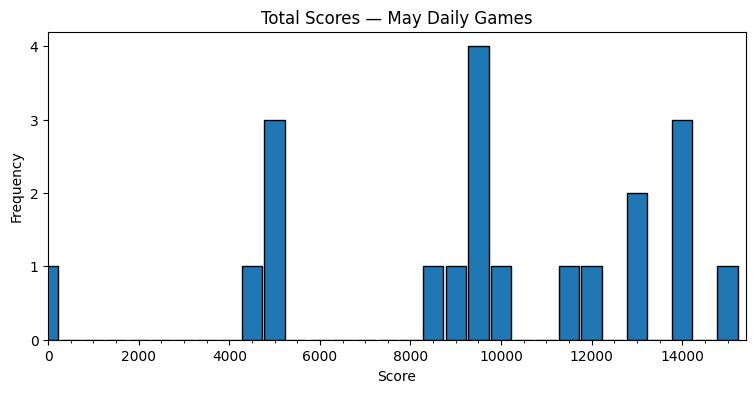

In [28]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

bins = np.arange(-250, 15750, 500)

plt.figure(figsize=(9, 4))

plt.hist(scores, bins=bins, edgecolor='black', rwidth=0.9)

ax = plt.gca()

plt.xticks(np.arange(0, 16000, 2000))
ax.xaxis.set_minor_locator(MultipleLocator(500))

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim(0, 15400)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Total Scores — May Daily Games')

plt.show()

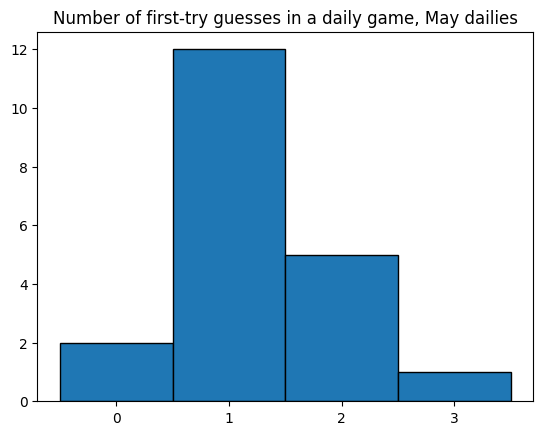

In [29]:
plt.hist(first_tries, bins=np.arange(-0.5, 4.5, 1), ec='black');
plt.xticks([0, 1, 2, 3])
plt.title('Number of first-try guesses in a daily game, May dailies');
plt.show()

In [33]:
play_daily_game_from_date("5/20/2026", rf, mlb, show_predictions=True, explainer=explainer, show_lime=True)

Dish 1: Yau Gok
Countries/territories of origin: ['Hong Kong', 'Macau', 'China']
Ingredients: Glutinous rice flour, wheat flour, sugar, peanuts, sesame seeds, coconut, vegetable oil, water, salt, five-spice powder, (optional) dried tangerine peel, (optional) almond paste, (optional).
Processed ingredients: ['vegetable_oil', 'dried_tangerine_peel', 'water', 'vegetable', 'coconut', 'five_spice_powder', 'salt', 'peanut', 'rice', 'sugar', 'wheat', 'glutinou_rice_flour', 'sesame_seed', 'wheat_flour', 'almond_paste', 'spice', 'oil', 'flour', 'almond']
Prediction 1: South Korea (13.45%)
Prediction 2: Malaysia (9.78%)
Prediction 3: China (8.36%)
Prediction 4: Vietnam (6.08%)
Prediction 5: North Korea (5.27%)


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['dried_tangerine_peel'] will be ignored
  warnings.warn(



Top contributing ingredients:
sesame_seed: 0.0289
rice: 0.0112
almond_paste: 0.0112
five_spice_powder: 0.0049
glutinou_rice_flour: 0.0046
Round score: 4000

Dish 2: Hawawshi
Countries/territories of origin: ['Egypt']
Ingredients: Ground meat, onion, tomato, green pepper, garlic, coriander, cumin, cinnamon, allspice, salt, black pepper, red pepper, parsley, bread, chili pepper (optional), paprika (optional), butter (optional), ghee (optional), cheese (optional).
Processed ingredients: ['red_pepper', 'tomato', 'coriander', 'ground_meat', 'butter', 'green_pepper', 'cumin', 'black_pepper', 'paprika', 'salt', 'garlic', 'pepper', 'chili', 'allspice', 'ghee', 'parsley', 'meat', 'onion', 'cheese', 'chili_pepper', 'bread', 'cinnamon']
Prediction 1: Egypt (8.16%)
Prediction 2: Georgia (7.01%)
Prediction 3: India (5.08%)
Prediction 4: Turkey (4.38%)
Prediction 5: Nepal (4.05%)

Top contributing ingredients:
cumin: 0.0141
ghee: 0.0139
cinnamon: 0.0029
chili_pepper: 0.0026
paprika: -0.0023
First t

(14000, 2)

In [31]:
model_df[model_df['countries_of_origin'].apply(lambda x: 'Armenia' in x and len(x) < 4)]

,dish_name,countries_of_origin,ingredients
429,Mikado Cake,[Armenia],"[walnut, condensed_milk, vanilla, sugar, egg, ..."
453,Matsoni,"[Armenia, Georgia, Azerbaijan]","[yogurt_starter, yogurt, milk]"
738,Tel Panir,[Armenia],"[rennet, mint, vinegar, water, nigella_seed, c..."
836,Chicken Tabaka,"[Armenia, Georgia, Azerbaijan]","[pepper, oil, paprika, black_pepper, garlic, b..."
868,Ajapsandali,"[Armenia, Georgia, Azerbaijan]","[eggplant, bell_pepper, potato, parsley, peppe..."
946,Lula Kebab,"[Armenia, Georgia, Azerbaijan]","[parsley, pepper, coriander, onion, black_pepp..."
1169,Tsoureki,"[Armenia, Greece]","[orange_zest, butter, vanilla, sugar, egg, rai..."
1226,Stuffed Quinces,"[Armenia, Iran, Turkey]","[sugar, oil, beef, tomato, ground_lamb, salt, ..."
1335,Khorovats,[Armenia],"[oil, chicken, garlic, lamb, mushroom, beef, t..."
1464,Ghapama,[Armenia],"[dried_fruit, sugar, fruit, honey, pumpkin, ci..."


### misc

In [32]:
predict_country_with_model("dubai chocolate crumbl cookie matcha latte baja blast pie", rf, mlb)

Processed ingredients: ['chocolate', 'dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie']
Prediction 1: United States (6.27%)
Prediction 2: United Kingdom (5.71%)
Prediction 3: France (4.83%)
Prediction 4: Germany (4.56%)
Prediction 5: Canada (3.89%)


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie'] will be ignored
  warnings.warn(


['United States', 'United Kingdom', 'France', 'Germany', 'Canada']

# Model Interpretability + Stats

Goals:
- show why model made a prediction in a specific case **✓** (LIME does an okay job for "positive" contributions, ie. which ingredients in the list are most important)
- show what ingredient combinations are good predictors for each country's cuisine **✓**
- cluster countries by their ingredient lists

### LIME testing

In [34]:
foods_dict = {
    "Baghali Polo":{"Rice, dill, fava beans, saffron, oil, salt, turmeric, garlic, onion, lamb (optional), chicken (optional), butter (optional), cinnamon (optional).":["Iran"]},
    "Kaeng yot maphrao sai kai":{"Chicken, coconut shoots, coconut milk, red curry paste, fish sauce, palm sugar, kaffir lime leaves, basil, (optional) bamboo shoots, (optional) eggplant, (optional) fresh chilies, (optional) garlic, (optional) shallots":["Thailand"]},
    "Castagnaccio":{"Chestnut flour, water, olive oil, pine nuts, raisins, rosemary, walnuts (optional), orange zest (optional), fennel seeds (optional), sugar (optional), salt.":["Italy"]}
}
play_daily_game(foods_dict, rf, mlb, show_predictions=True, explainer=explainer, show_lime=True)

Dish 1: Baghali Polo
Countries/territories of origin: ['Iran']
Ingredients: Rice, dill, fava beans, saffron, oil, salt, turmeric, garlic, onion, lamb (optional), chicken (optional), butter (optional), cinnamon (optional).
Processed ingredients: ['turmeric', 'fava_bean', 'dill', 'chicken', 'saffron', 'butter', 'rice', 'salt', 'cinnamon', 'lamb', 'onion', 'bean', 'oil', 'garlic']
Prediction 1: Iran (20.73%)
Prediction 2: Azerbaijan (6.01%)
Prediction 3: Turkey (4.22%)
Prediction 4: Georgia (3.75%)
Prediction 5: Peru (3.40%)

Top contributing ingredients:
turmeric: 0.0471
saffron: 0.0409
fava_bean: 0.0100
lamb: 0.0089
dill: 0.0022
First try!
Round score: 5000

Dish 2: Kaeng yot maphrao sai kai
Countries/territories of origin: ['Thailand']
Ingredients: Chicken, coconut shoots, coconut milk, red curry paste, fish sauce, palm sugar, kaffir lime leaves, basil, (optional) bamboo shoots, (optional) eggplant, (optional) fresh chilies, (optional) garlic, (optional) shallots
Processed ingredients:

/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['coconut_shoot'] will be ignored
  warnings.warn(



Top contributing ingredients:
red_curry_paste: 0.0644
fresh_chili: 0.0398
fish_sauce: 0.0321
palm_sugar: 0.0308
coconut_milk: 0.0211
First try!
Round score: 5000

Dish 3: Castagnaccio
Countries/territories of origin: ['Italy']
Ingredients: Chestnut flour, water, olive oil, pine nuts, raisins, rosemary, walnuts (optional), orange zest (optional), fennel seeds (optional), sugar (optional), salt.
Processed ingredients: ['sugar', 'flour', 'nut', 'orange', 'fennel_seed', 'orange_zest', 'chestnut_flour', 'salt', 'fennel', 'water', 'walnut', 'olive', 'chestnut', 'raisin', 'oil', 'olive_oil', 'rosemary', 'pine_nut']
Prediction 1: Italy (22.53%)
Prediction 2: Greece (22.21%)
Prediction 3: France (14.50%)
Prediction 4: Spain (6.60%)
Prediction 5: Turkey (3.64%)

Top contributing ingredients:
olive_oil: 0.0619
chestnut_flour: 0.0355
olive: 0.0309
rosemary: 0.0218
fennel: 0.0047
First try!
Round score: 5000

Results:
Overall score: 15000
3 out of 3 correct first try


### Find useful ingredients to distinguish each country

#### Let's try log-odds!

In [119]:
# get every pair of ingredients, excluding the base ingredients vs processed ingredient pairs
from itertools import combinations

ingredients = unique_dishes_df["ingredients"].explode().unique()

pairs = set()

for ing1, ing2 in combinations(sorted(ingredients), 2):

    tokens1 = set(ing1.split("_"))
    tokens2 = set(ing2.split("_"))

    if tokens1.issubset(tokens2) or tokens2.issubset(tokens1):
        continue

    pairs.add((ing1, ing2))

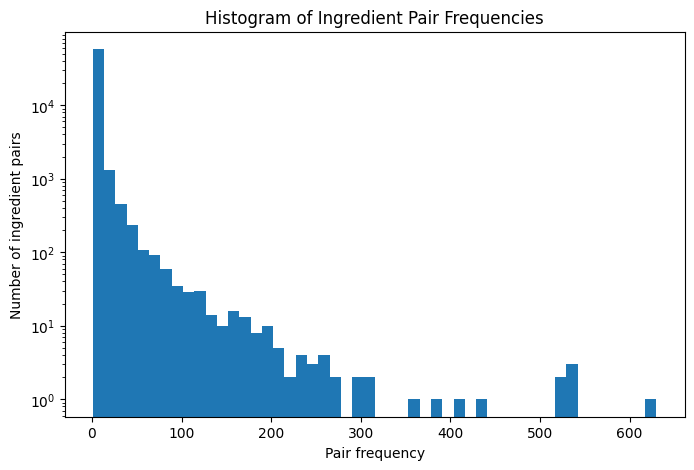

In [120]:
# filter for more common pairs
from collections import Counter

pair_counts = Counter()

# count ingredient pairs per dish
for ingredients in unique_dishes_df["ingredients"]:

    ingredients = sorted(set(ingredients))  # remove duplicates within dish

    for pair in combinations(ingredients, 2):
        pair_counts[pair] += 1

# convert to dataframe
pair_freq_df = pd.DataFrame(
    [
        {
            "ingredient_1": pair[0],
            "ingredient_2": pair[1],
            "frequency": count
        }
        for pair, count in pair_counts.items()
    ]
)

# optional: sort descending
pair_freq_df = pair_freq_df.sort_values(
    "frequency",
    ascending=False
)

# histogram
plt.figure(figsize=(8, 5))
plt.hist(pair_freq_df["frequency"], bins=50)

plt.xlabel("Pair frequency")
plt.ylabel("Number of ingredient pairs")
plt.title("Histogram of Ingredient Pair Frequencies")
plt.yscale("log")

plt.show()

In [121]:
# find pairs that appear at least 10 times
filtered_pair_df = pair_freq_df[pair_freq_df["frequency"] >= 10]

# remove pairs containing salt or pepper
filtered_pair_df = filtered_pair_df[
    ~(
        filtered_pair_df["ingredient_1"].str.contains("salt|pepper")
        |
        filtered_pair_df["ingredient_2"].str.contains("salt|pepper")
    )
]

filtered_ingredient_pairs = list(
    zip(
        filtered_pair_df["ingredient_1"],
        filtered_pair_df["ingredient_2"]
    )
)

# find ingredients that appear at least twice...filters out some weird descriptions and ingredients that may not be informative beyond a specific dish
counts = unique_dishes_df["ingredients"].explode().value_counts()
filtered_ingredients = counts[counts >= 2].index

len(filtered_ingredient_pairs), len(filtered_ingredients)

(2956, 957)

In [122]:
country = "Peru"

alpha = 1  # smoothing constant

# count dishes
country_mask = unique_dishes_df["countries_of_origin"].apply(
    lambda countries: country in countries
)

country_df = unique_dishes_df[country_mask]
rest_df = unique_dishes_df[~country_mask]

N_country = len(country_df)
N_rest = len(rest_df)

# initialize counters
country_counts = Counter()
rest_counts = Counter()

# helper function
def extract_features(ingredients):

    ingredients = set(ingredients)

    features = set()

    # single ingredients
    for ing in ingredients:
        if ing in filtered_ingredients:
            features.add(ing)

    # ingredient pairs
    ingredient_pairs_in_dish = {
        tuple(sorted(pair))
        for pair in combinations(sorted(ingredients), 2)
    }

    for pair in ingredient_pairs_in_dish:
        if pair in filtered_ingredient_pairs:
            features.add(pair)

    return features

# count country features
for ingredients in country_df["ingredients"]:

    features = extract_features(ingredients)

    for feature in features:
        country_counts[feature] += 1

# count rest-of-world features
for ingredients in rest_df["ingredients"]:

    features = extract_features(ingredients)

    for feature in features:
        rest_counts[feature] += 1

# all observed features
all_features = (
    set(country_counts.keys())
    | set(rest_counts.keys())
)

# compute log odds
results = []

for feature in all_features:

    c_i = country_counts[feature]
    r_i = rest_counts[feature]

    odds_country = (
        (c_i + alpha)
        /
        (N_country - c_i + alpha)
    )

    odds_rest = (
        (r_i + alpha)
        /
        (N_rest - r_i + alpha)
    )

    log_odds = np.log(odds_country / odds_rest)

    # frequency-weighted score
    weighted_score = log_odds * (1 + 0.5 * np.log1p(c_i))

    results.append({
        "feature": feature,
        "country_count": c_i,
        "rest_count": r_i,
        "log_odds": log_odds,
        "weighted_score": weighted_score
    })

# dataframe of results
log_odds_df = pd.DataFrame(results)

# sort by weighted score instead
log_odds_df = log_odds_df.sort_values(
    "weighted_score",
    ascending=False
)

num_dishes = unique_dishes_df["countries_of_origin"].apply(
    lambda countries: country in countries
).sum()

print(f"Number of unique dishes from {country}: {num_dishes}")
print(log_odds_df.head(20))

def foods_for_country(country):
    return unique_dishes_df[
        unique_dishes_df["countries_of_origin"].apply(
            lambda countries: country in countries
        )
    ]

foods_for_country(country).head(10)

Number of unique dishes from Peru: 35
                        feature  country_count  rest_count  log_odds  \
3425               aji_amarillo              7           0  6.155224   
1370                  aji_panca              3           0  5.332865   
1854         aji_amarillo_paste              2           0  5.015330   
2574             chinese_noodle              2           0  5.015330   
703                    raw_fish              2           1  4.321597   
2523          (oregano, potato)              4           6  3.637351   
94              (corn, parsley)              4           6  3.637351   
3436                (corn, pea)              5          11  3.309483   
2342             (corn, potato)              8          27  2.959960   
3633         (cumin, vegetable)              4           8  3.384861   
3242              (cumin, lime)              5          13  3.154153   
3393            (cilantro, pea)              4           9  3.278912   
2698              (pea, po

,dish_name,countries_of_origin,ingredients
50,Picarón,"[Peru, Chile]","[pumpkin, clove, sugar, potato, cinnamon, egg,..."
140,Olluquito,[Peru],"[onion, olluco, red_onion, beef, potato, cilan..."
159,Inca Kola,[Peru],"[sugar, carbonated_water, yellow_dye, citru_ex..."
218,Alpaca en salsa de aguaymanto,[Peru],"[onion, alpaca_meat, wine, chili, sugar, black..."
372,Lomo Saltado,[Peru],"[onion, rice, cumin, beef, garlic, french_fry,..."
378,Sancochado,[Peru],"[cabbage, onion, black_pepper, potato, chickpe..."
436,Aeropuerto,[Peru],"[onion, shrimp, oil, rice, vegetable, noodle, ..."
455,Cuy,"[Peru, Colombia, Bolivia, Ecuador]","[wheat, onion, achiote, cumin, flour, wheat_fl..."
458,Ceviche,[Peru],"[onion, corn, chili, fish, lettuce, red_onion,..."
478,Salchipapa,"[Brazil, French Guiana, Uruguay, Guyana, Peru,...","[ketchup, hot_dog, lettuce, mayonnaise, mustar..."


#### export top 5 pairs, top 5 single ingredients for every country and territory with at least 10 dishes

In [125]:
from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd


alpha = 1
min_dishes = 10


# ---------- helper function ----------
def extract_features(ingredients):

    ingredients = set(ingredients)

    features = set()

    # single ingredients
    for ing in ingredients:
        if ing in filtered_ingredients:
            features.add(ing)

    # ingredient pairs
    ingredient_pairs_in_dish = {
        tuple(sorted(pair))
        for pair in combinations(sorted(ingredients), 2)
    }

    for pair in ingredient_pairs_in_dish:
        if pair in filtered_ingredient_pairs:
            features.add(pair)

    return features


# ---------- main function ----------
def export_country_feature_scores(country_list, output_csv="country_feature_scores.csv"):

    all_country_results = []

    for country in country_list:

        print(f"Processing {country}...")

        # country vs rest split
        country_mask = unique_dishes_df["countries_of_origin"].apply(
            lambda countries: country in countries
        )

        country_df = unique_dishes_df[country_mask]
        rest_df = unique_dishes_df[~country_mask]

        N_country = len(country_df)
        N_rest = len(rest_df)

        # skip countries with too few dishes
        if N_country < min_dishes:
            print(f"Skipping {country} (< {min_dishes} dishes)")
            continue

        country_counts = Counter()
        rest_counts = Counter()

        # count features in country dishes
        for ingredients in country_df["ingredients"]:

            features = extract_features(ingredients)

            for feature in features:
                country_counts[feature] += 1

        # count features in rest-of-world dishes
        for ingredients in rest_df["ingredients"]:

            features = extract_features(ingredients)

            for feature in features:
                rest_counts[feature] += 1

        all_features = (
            set(country_counts.keys())
            | set(rest_counts.keys())
        )

        results = []

        for feature in all_features:

            c_i = country_counts[feature]
            r_i = rest_counts[feature]

            odds_country = (
                (c_i + alpha)
                /
                (N_country - c_i + alpha)
            )

            odds_rest = (
                (r_i + alpha)
                /
                (N_rest - r_i + alpha)
            )

            log_odds = np.log(odds_country / odds_rest)

            # frequency-weighted score
            weighted_score = log_odds * (1 + 0.5 * np.log1p(c_i))

            results.append({
                "feature": feature,
                "country_count": c_i,
                "rest_count": r_i,
                "log_odds": log_odds,
                "weighted_score": weighted_score,
                "feature_type": "pair" if isinstance(feature, tuple) else "ingredient"
            })

        results_df = pd.DataFrame(results)

        # ---------- top single ingredients ----------
        top_ingredients = (
            results_df[
                results_df["feature_type"] == "ingredient"
            ]
            .sort_values("weighted_score", ascending=False)
            .head(5)
            .copy()
        )

        top_ingredients["country"] = country

        # ---------- top ingredient pairs ----------
        top_pairs = (
            results_df[
                results_df["feature_type"] == "pair"
            ]
            .sort_values("weighted_score", ascending=False)
            .head(5)
            .copy()
        )

        top_pairs["country"] = country

        # convert tuples to strings for CSV readability
        top_pairs["feature"] = top_pairs["feature"].apply(
            lambda x: " + ".join(x)
        )

        all_country_results.append(top_ingredients)
        all_country_results.append(top_pairs)

    # combine all countries
    final_df = pd.concat(all_country_results, ignore_index=True)

    # export
    final_df.to_csv(output_csv, index=False)

    print(f"Saved results to: {output_csv}")

    return final_df

In [126]:
country_list = [
        "Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Argentina", "Armenia", 
        "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", 
        "Belarus", "Belgium", "Belize", "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", 
        "Botswana", "Brazil", "Brunei", "Bulgaria", "Burkina Faso", "Burundi", "Cambodia", 
        "Cameroon", "Canada", "Cape Verde", "Central African Republic", "Chad", "Chile", "China", 
        "Colombia", "Comoros", "Congo", "Costa Rica", "Croatia", "Cuba", "Cyprus", "Czech Republic", 
        "Czechia", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", 
        "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Fiji", 
        "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada", 
        "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hungary", "Iceland", 
        "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Jamaica", "Japan", 
        "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan", "Laos", "Latvia", 
        "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein", "Lithuania", "Luxembourg", 
        "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", 
        "Mauritania", "Mauritius", "Mexico", "Micronesia", "Moldova", "Monaco", "Mongolia", 
        "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", 
        "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway", 
        "Oman", "Pakistan", "Palau", "Palestine", "Panama", "Papua New Guinea", "Paraguay", "Peru", 
        "Philippines", "Poland", "Portugal", "Qatar", "Romania", "Russia", "Rwanda", "Saint Kitts and Nevis", 
        "Saint Lucia", "Saint Vincent and the Grenadines", "Samoa", "San Marino", "Sao Tome and Principe", 
        "Saudi Arabia", "Senegal", "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", 
        "Slovenia", "Solomon Islands", "Somalia", "South Africa", "South Korea", "South Sudan", "Spain", 
        "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria", "Taiwan", "Tajikistan", 
        "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga", "Trinidad and Tobago", "Tunisia", 
        "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", 
        "United States", "Uruguay", "Uzbekistan", "Vanuatu", "Vatican City", "Venezuela", "Vietnam", 
        "Yemen", "Zambia", "Zimbabwe",
        "Hong Kong", "Macau", "Palestine", "Puerto Rico", "Greenland", "Faroe Islands", "French Guiana", "Gibraltar",
        "Isle of Man", "Jersey", "Guernsey", "Aruba", "Curacao", "Sint Maarten", "Bonaire", "Saba", "Saint Barthélemy",
        "Saint Martin", "Saint Pierre and Miquelon", "Wallis and Futuna", "Western Sahara", "Kosovo", "Antigua and Barbuda", "Curaçao",
        "Saint Helena, Ascension and Tristan da Cunha", "Cook Islands", "Niue", "Tokelau", "Åland Islands", "Ivory Coast", "Côte d'Ivoire",
        "French Southern and Antarctic Lands", "Réunion", "Mayotte", "Guadaloupe", "Martinique", "Saint Pierre and Miquelon",
        "Bermuda", "British Virgin Islands", "Falkland Islands", "Montserrat", "Turks and Caicos Islands", "Virgin Islands",
        "Guadeloupe", "Cayman Islands", "Republic of the Congo", "São Tomé and Príncipe", "DR Congo", "American Samoa",  "French Polynesia",
        "Cocos (Keeling) Islands", "Christmas Island", "Guam"
]

results_df = export_country_feature_scores(country_list)

Processing Afghanistan...
Processing Albania...
Skipping Albania (< 10 dishes)
Processing Algeria...
Processing Andorra...
Skipping Andorra (< 10 dishes)
Processing Angola...
Skipping Angola (< 10 dishes)
Processing Argentina...
Processing Armenia...
Processing Australia...
Processing Austria...
Processing Azerbaijan...
Processing Bahamas...
Skipping Bahamas (< 10 dishes)
Processing Bahrain...
Processing Bangladesh...
Processing Barbados...
Skipping Barbados (< 10 dishes)
Processing Belarus...
Processing Belgium...
Processing Belize...
Skipping Belize (< 10 dishes)
Processing Benin...
Skipping Benin (< 10 dishes)
Processing Bhutan...
Skipping Bhutan (< 10 dishes)
Processing Bolivia...
Processing Bosnia and Herzegovina...
Processing Botswana...
Skipping Botswana (< 10 dishes)
Processing Brazil...
Processing Brunei...
Processing Bulgaria...
Processing Burkina Faso...
Skipping Burkina Faso (< 10 dishes)
Processing Burundi...
Skipping Burundi (< 10 dishes)
Processing Cambodia...
Processing

#### Remnant of debugging... real ones will remember rice is made of ice...

In [123]:
ice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings
).sum()

rice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "rice" in ings
).sum()

ice_rice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings and "rice" in ings
).sum()

print("Dishes with ice:", ice_count)
print("Dishes with rice:", rice_count)
print("Dishes with both:", ice_rice_count)

Dishes with ice: 37
Dishes with rice: 297
Dishes with both: 4


In [124]:
unique_dishes_df[unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings and "rice" in ings
)]

,dish_name,countries_of_origin,ingredients
30,Shwe Yin Aye,[Myanmar],"[coconut_milk, rice, ice, sugar, pandan_leaf, ..."
887,Khao Chae,[Thailand],"[coconut_milk, turmeric, ice, shrimp, kaffir_l..."
1378,Namkhaeng Sai,[Thailand],"[coconut_cream, jackfruit, ice, milk, fruit, g..."
1587,Cendol,"[Brunei, Malaysia, Cambodia, Vietnam, Indonesi...","[coconut_milk, red_bean, corn, rice, rice_flou..."


In [45]:
display_ingredients("Khao Chae")

'jasmine rice, water, flower-scented water, ice sides include shrimp paste, shallots, garlic, dried fish, pork, sugar, salt, turmeric, white pepper, coconut milk, chilies, lemongrass, ginger, coriander, kaffir lime leaves, roasted rice powder, peanuts, mung beans, pickled vegetables'